In [2]:
import sys
sys.path.append("../src")
from parse_pcap import parsing_pcap
import pandas as pd

df = parsing_pcap("../data/capture.pcap")
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
print(f"{len(df)} paquets chargés")
df.head(10)

6 paquets chargés


,timestamp,src_ip,dst_ip,length,ttl,protocol,src_port,dst_port,flags,datetime
0,1.169051e+09,127.0.0.1,127.0.0.1,138,64,ICMP,None,None,None,2007-01-17 16:23:29.047982931
1,1.169051e+09,127.0.0.1,127.0.0.1,138,64,ICMP,None,None,None,2007-01-17 16:23:29.051067114
2,1.169051e+09,127.0.0.1,127.0.0.1,122,64,ICMP,None,None,None,2007-01-17 16:23:46.790916920
3,1.169051e+09,127.0.0.1,127.0.0.1,122,64,ICMP,None,None,None,2007-01-17 16:23:46.793504000
4,1.169051e+09,127.0.0.1,127.0.0.1,122,64,ICMP,None,None,None,2007-01-17 16:24:05.325824022
5,1.169051e+09,127.0.0.1,127.0.0.1,122,64,ICMP,None,None,None,2007-01-17 16:24:05.325879097


In [3]:
# Comptage des protocoles
protocol_counts = df["protocol"].value_counts()
protocol_pct = df["protocol"].value_counts(normalize=True) * 100

print(protocol_counts)
print("\nEn pourcentage :")
print(protocol_pct.round(2))

protocol
ICMP    6
Name: count, dtype: int64

En pourcentage :
protocol
ICMP    100.0
Name: proportion, dtype: float64


In [4]:
# Top talkers par nombre de paquets envoyés
top_src_count = df["src_ip"].value_counts().head(10)
print("\nTop 10 IP source par nombre de paquets envoyés :")
print(top_src_count)

# Top talkers par volume de données envoyées
top_src_bytes = df.groupby("src_ip")["length"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 IP source par volume de données envoyées :")
print(top_src_bytes)

# Top talkers par nombre de paquets reçus
top_dst_count = df["dst_ip"].value_counts().head(10)
print("\nTop 10 IP destination par nombre de paquets reçus :")
print(top_dst_count)

# Top talkers par volume de données reçues
top_dst_bytes = df.groupby("dst_ip")["length"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 IP destination par volume de données reçues :")
print(top_dst_bytes)


Top 10 IP source par nombre de paquets envoyés :
src_ip
127.0.0.1    6
Name: count, dtype: int64

Top 10 IP source par volume de données envoyées :
src_ip
127.0.0.1    764
Name: length, dtype: int64

Top 10 IP destination par nombre de paquets reçus :
dst_ip
127.0.0.1    6
Name: count, dtype: int64

Top 10 IP destination par volume de données reçues :
dst_ip
127.0.0.1    764
Name: length, dtype: int64


count      6.000000
mean     127.333333
std        8.262364
min      122.000000
25%      122.000000
50%      122.000000
75%      134.000000
max      138.000000
Name: length, dtype: float64


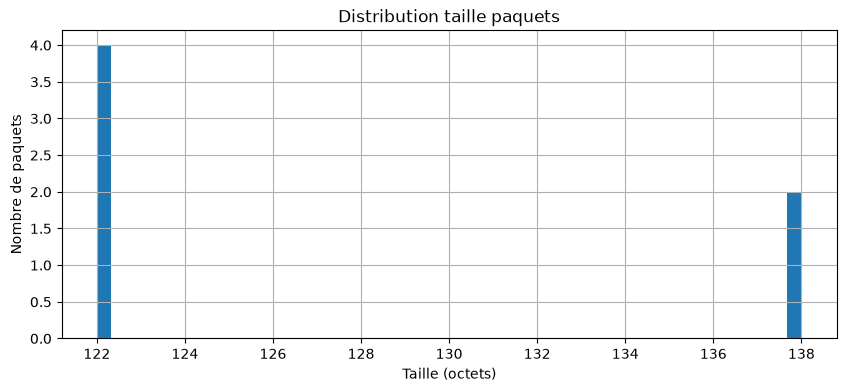

In [5]:
print(df["length"].describe())

# Détecter les anomalies dans la taille des paquets
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
df["length"].hist(bins=50)
plt.title("Distribution taille paquets")
plt.xlabel("Taille (octets)")
plt.ylabel("Nombre de paquets")
plt.show()

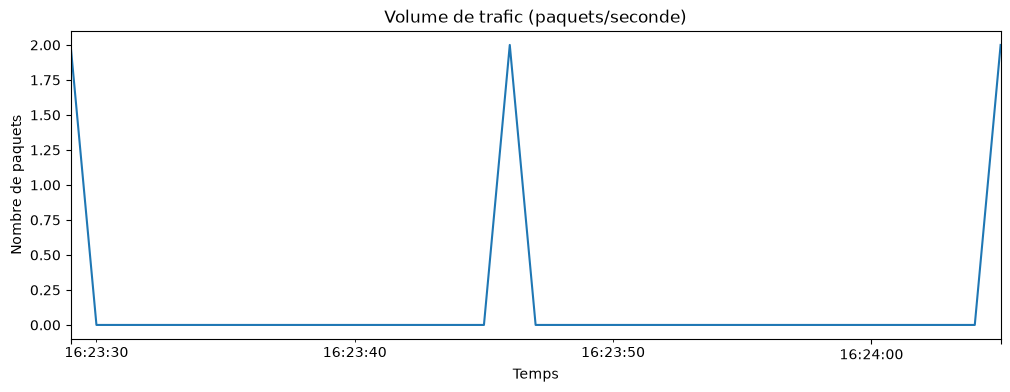

In [6]:
# Regrouper par fenetre de temps
df_time = df.set_index("datetime")
traffic_per_sec = df_time.resample("1s").size() #nb de pquuets/sec

plt.figure(figsize=(12, 4))
traffic_per_sec.plot()
plt.title("Volume de trafic (paquets/seconde)")
plt.xlabel("Temps")
plt.ylabel("Nombre de paquets")
plt.show()

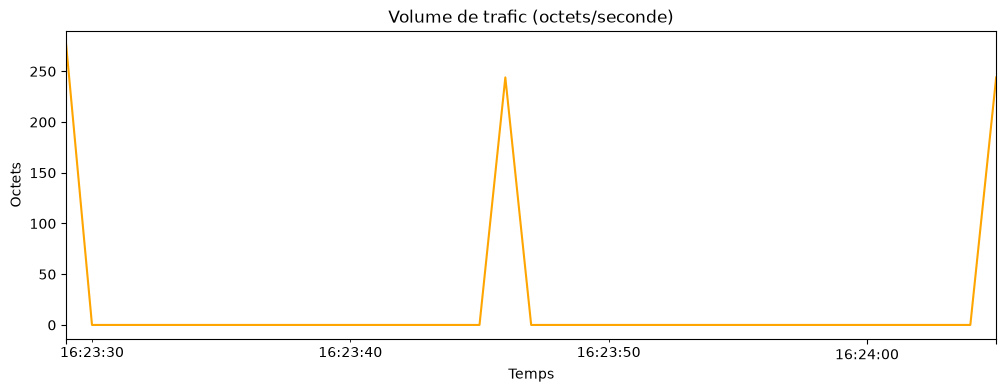

In [7]:
# Volume en octets plutot que par nbr de paquets
bytes_per_sec = df_time.resample("1s")["length"].sum()

plt.figure(figsize=(12, 4))
bytes_per_sec.plot(color="orange")
plt.title("Volume de trafic (octets/seconde)")
plt.xlabel("Temps")
plt.ylabel("Octets")
plt.show()

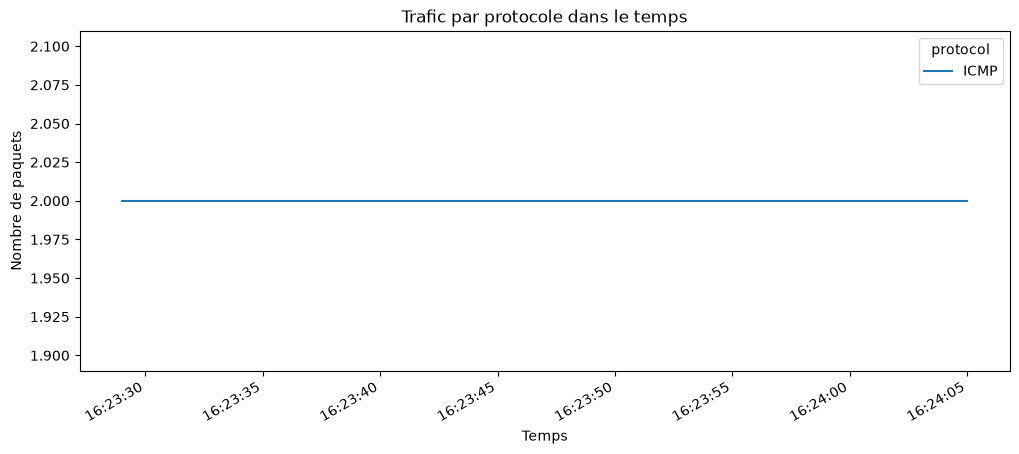

In [8]:
# Voir si un protocole domine à un instant donné
traffic_by_protocol = df_time.groupby([pd.Grouper(freq="1s"), "protocol"]).size().unstack(fill_value=0)

traffic_by_protocol.plot(figsize=(12, 5), stacked=True)
plt.title("Trafic par protocole dans le temps")
plt.xlabel("Temps")
plt.ylabel("Nombre de paquets")
plt.show()

In [9]:
# Ports les plus utilisés

top_dst_ports = df["dst_port"].value_counts().head(10)
print("\nTop 10 ports destination les plus utilisés :")
print(top_dst_ports)

# Nbr ports distincts contactés par IP source -> signe de scan
ports_per_src = df.groupby("src_ip")["dst_port"].nunique().sort_values(ascending=False).head(10)
print("\nNombre de ports distincts contactés par IP source :")
print(ports_per_src)


Top 10 ports destination les plus utilisés :
Series([], Name: count, dtype: int64)

Nombre de ports distincts contactés par IP source :
src_ip
127.0.0.1    0
Name: dst_port, dtype: int64


In [ ]:
import sys
sys.path.append("../src")
from detect_anomalies_zscore import detect_anomalies_zscore

# Application de la fonction sur un exemple

df_time = df.set_index("datetime")
traffic_per_sec = df_time.resample("1s").size()

anomalies = detect_anomalies_zscore(traffic_per_sec, threshold=3.0)
print(f"Nombre d'anomalies détectées : {anomalies['is_anomaly'].sum()}")
print(anomalies[anomalies['is_anomaly']])

ImportError: cannot import name 'detect_anomalies_mad' from 'detect_anomalies_zscore' (c:\Users\lucie\git repo\Netwrok Scanner\notebooks\../src\detect_anomalies_zscore.py)

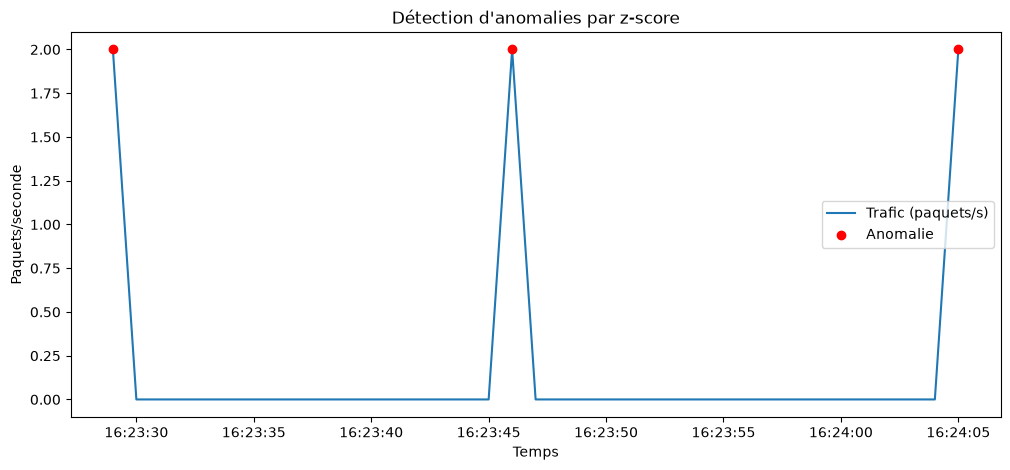

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(anomalies.index, anomalies["value"], label="Trafic (paquets/s)")
plt.scatter(
    anomalies[anomalies["is_anomaly"]].index,
    anomalies[anomalies["is_anomaly"]]["value"],
    color="red", label="Anomalie", zorder=5
)
plt.title("Détection d'anomalies par z-score")
plt.xlabel("Temps")
plt.ylabel("Paquets/seconde")
plt.legend()
plt.show()